In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from matplotlib import patches
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
import pandas as pd
from collections import defaultdict
from cyvcf2 import VCF, Writer

## Mendelian consistency analysis on 1KG trios
Check this link for more info:
https://github.com/mobinasri/research_notes/tree/main/DeepVariant_Pangenome/Mendelian_Consistency_1KG

In [2]:
#!wget https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000G_2504_high_coverage/working/1kGP.3202_samples.pedigree_info.txt

--2026-03-02 14:17:40--  https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000G_2504_high_coverage/working/1kGP.3202_samples.pedigree_info.txt
Resolving ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)... 193.62.193.167
Connecting to ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)|193.62.193.167|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 52119 (51K) [text/plain]
Saving to: ‘1kGP.3202_samples.pedigree_info.txt’

1kGP.3202_samples.p 100%[===================>]  50.90K   301KB/s    in 0.2s    

2026-03-02 14:17:41 (301 KB/s) - ‘1kGP.3202_samples.pedigree_info.txt’ saved [52119/52119]



### Parse 1KG trio information and separate trios with male and female child

In [27]:
pedigree_info_table = pd.read_csv("1kGP.3202_samples.pedigree_info.txt", sep=" ")
only_pedigree_table_female = pd.DataFrame(columns=["sampleID", "fatherID", "motherID", "sex"])
only_pedigree_table_male = pd.DataFrame(columns=["sampleID", "fatherID", "motherID", "sex"])

for i in range(pedigree_info_table.shape[0]):
    row = pedigree_info_table.iloc[i]
    if row["fatherID"] != "0" and row["motherID"] != "0":
        if row["sex"] == 2:
            # only trios whose children are female
            only_pedigree_table_female.loc[len(only_pedigree_table_female)] = row
        else:
            # only trios whose children are male
            only_pedigree_table_male.loc[len(only_pedigree_table_male)] = row

In [28]:
only_pedigree_table_male

,sampleID,fatherID,motherID,sex
0,HG00420,HG00418,HG00419,1
1,HG00429,HG00427,HG00428,1
2,HG00444,HG00442,HG00443,1
3,HG00459,HG00457,HG00458,1
4,HG00465,HG00463,HG00464,1
...,...,...,...,...
305,NA19828,NA19818,NA19819,1
306,NA19918,NA19916,NA19917,1
307,NA19919,NA19908,NA19909,1
308,NA20279,NA20278,NA20282,1


In [29]:
only_pedigree_table_female

,sampleID,fatherID,motherID,sex
0,HG00405,HG00403,HG00404,2
1,HG00408,HG00406,HG00407,2
2,HG00423,HG00421,HG00422,2
3,HG00438,HG00436,HG00437,2
4,HG00447,HG00445,HG00446,2
...,...,...,...,...
287,NA19902,NA19900,NA19901,2
288,NA19924,NA19922,NA19923,2
289,NA19983,NA19982,NA19713,2
290,NA20128,NA20126,NA20127,2


## Take only the trios that are present in DV vcf files

In [30]:
pangenome_aware_sample_names = [i.strip() for i in open("pangenome_aware_sample_names.txt","r").readlines()]
linear_ref_based_sample_names = [i.strip() for i in open("linear_ref_based_sample_names.txt","r").readlines()]

In [31]:
# checking that pangenome-aware DV and linear-ref-based DV were run on exactly the same samples
i = 0
for x in pangenome_aware_sample_names:
    if x.strip().split('_')[-1] in linear_ref_based_sample_names:
        i += 1
print(i, len(pangenome_aware_sample_names), len(linear_ref_based_sample_names))
available_samples = linear_ref_based_sample_names

3202 3202 3202


In [32]:
available_indices = []
for i in range(only_pedigree_table_male.shape[0]):
    row = only_pedigree_table_male.iloc[i]
    sample_id = row["sampleID"]
    father_id = row["fatherID"]
    mother_id = row["motherID"]
    if sample_id in available_samples and father_id in available_samples and mother_id in available_samples:
        available_indices.append(i)
only_pedigree_table_male_available = only_pedigree_table_male.iloc[available_indices]
print("Out of ", len(only_pedigree_table_male), "trios with male child,", len(only_pedigree_table_male_available)," are available!" )

Out of  310 trios with male child, 310  are available!


In [33]:
available_indices = []
for i in range(only_pedigree_table_female.shape[0]):
    row = only_pedigree_table_female.iloc[i]
    sample_id = row["sampleID"]
    father_id = row["fatherID"]
    mother_id = row["motherID"]
    if sample_id in available_samples and father_id in available_samples and mother_id in available_samples:
        available_indices.append(i)
only_pedigree_table_female_available = only_pedigree_table_female.iloc[available_indices]
print("Out of ", len(only_pedigree_table_female), "trios with female child,", len(only_pedigree_table_female_available)," are available!" )

Out of  292 trios with female child, 292  are available!


### Remove trios containing HPRC-v1.1 samples 

In [34]:
with open("../population_allele_freq_analysis/HPRC-v1.1/hprc_v1.1_samples.txt","r") as f:
    hprc_samples = [sample.strip() for sample in f.readlines()]
len(hprc_samples)

45

In [36]:
available_indices = []
for i in range(only_pedigree_table_male_available.shape[0]):
    row = only_pedigree_table_male_available.iloc[i]
    sample_id = row["sampleID"]
    father_id = row["fatherID"]
    mother_id = row["motherID"]
    if sample_id in hprc_samples or father_id in hprc_samples or mother_id in hprc_samples:
        continue
    available_indices.append(i)
only_pedigree_table_male_no_hprc = only_pedigree_table_male_available.iloc[available_indices]
print("Out of ", len(only_pedigree_table_male_available), "trios with male child,", len(only_pedigree_table_male_no_hprc)," contained no sample from HPRC-v1.1 panel" )

Out of  310 trios with male child, 294  contained no sample from HPRC-v1.1 panel


In [35]:
available_indices = []
for i in range(only_pedigree_table_female_available.shape[0]):
    row = only_pedigree_table_female_available.iloc[i]
    sample_id = row["sampleID"]
    father_id = row["fatherID"]
    mother_id = row["motherID"]
    if sample_id in hprc_samples or father_id in hprc_samples or mother_id in hprc_samples:
        continue
    available_indices.append(i)
only_pedigree_table_female_no_hprc = only_pedigree_table_female_available.iloc[available_indices]
print("Out of ", len(only_pedigree_table_female_available), "trios with female child,", len(only_pedigree_table_female_no_hprc)," contained no sample from HPRC-v1.1 panel" )

Out of  292 trios with female child, 269  contained no sample from HPRC-v1.1 panel


## Make a dictionary for mapping sample names in pangenome-aware DV vcf file
Note: Some of the names in pangenome-aware DV vcf are like "ERR3239276_NA06985", we need a dictionary to map "NA06985" it to "ERR3239276_NA06985". With that we can select trios with regular names and whenver necessary map it to the version in pangenome-aware DV vcf file.

In [73]:
!cat pangenome_aware_sample_names.txt | grep HG01524

ERR3241932_HG01524


In [77]:
"ERR3241932_HG01524".strip().split('_')[::-1][0]

'HG01524'

In [45]:
pangenome_aware_sample_name_mapper = {}
with open("pangenome_aware_sample_names.txt","r") as f:
    for sample_name in pangenome_aware_sample_names:
        second_name = sample_name.strip().split('_')[::-1][0]
        pangenome_aware_sample_name_mapper[second_name] = sample_name

In [37]:
# select 10 random male samples
n = 10
N = only_pedigree_table_male_no_hprc.shape[0]
random_indices = np.random.default_rng().choice(N, size=n, replace=False)
only_pedigree_table_male_selected = only_pedigree_table_male_no_hprc.iloc[random_indices]
only_pedigree_table_male_selected.to_csv("only_pedigree_table_male_selected.tsv",sep='\t', index=False)

In [38]:
only_pedigree_table_male_selected = pd.read_csv("only_pedigree_table_male_selected.tsv",sep="\t")
only_pedigree_table_male_selected

,sampleID,fatherID,motherID,sex
0,HG02686,HG02684,HG02685,1
1,HG01609,HG01608,HG01607,1
2,NA10865,NA11891,NA11892,1
3,HG02584,HG02582,HG02583,1
4,HG02838,HG02836,HG02837,1
5,NA12707,NA12716,NA12717,1
6,HG04215,HG03679,HG03642,1
7,HG02815,HG02813,HG02814,1
8,HG03942,HG03941,HG03940,1
9,HG01579,HG01577,HG01578,1


In [39]:
# select 10 random fmale samples
n = 10
N = only_pedigree_table_female_no_hprc.shape[0]
random_indices = np.random.default_rng().choice(N, size=n, replace=False)
only_pedigree_table_female_selected = only_pedigree_table_female_no_hprc.iloc[random_indices]
only_pedigree_table_female_selected.to_csv("only_pedigree_table_female_selected.tsv",sep='\t', index=False)

In [40]:
only_pedigree_table_female_selected = pd.read_csv("only_pedigree_table_female_selected.tsv",sep="\t")
only_pedigree_table_female_selected

,sampleID,fatherID,motherID,sex
0,HG01343,HG01341,HG01342,2
1,NA19659,NA19658,NA19657,2
2,HG03230,HG03228,HG03229,2
3,HG02495,HG02493,HG02494,2
4,NA18484,NA18486,NA18488,2
5,HG02785,HG02783,HG02784,2
6,HG03834,HG03833,HG03832,2
7,HG00700,HG00698,HG00699,2
8,HG01949,HG01947,HG01948,2
9,HG03719,HG03725,HG03722,2


In [41]:
male_trio_samples = np.array([list(only_pedigree_table_male_selected["sampleID"]), 
                              list(only_pedigree_table_male_selected["fatherID"]), 
                              list(only_pedigree_table_male_selected["motherID"])]).flatten()

In [42]:
female_trio_samples = np.array([list(only_pedigree_table_female_selected["sampleID"]), 
                                list(only_pedigree_table_female_selected["fatherID"]), 
                                list(only_pedigree_table_female_selected["motherID"])]).flatten()

In [46]:
all_selected_samples = np.array([male_trio_samples, female_trio_samples]).flatten()
with open("selected_trio_samples.txt","w") as f:
    f.write(",".join(all_selected_samples))
!cat selected_trio_samples.txt

HG02686,HG01609,NA10865,HG02584,HG02838,NA12707,HG04215,HG02815,HG03942,HG01579,HG02684,HG01608,NA11891,HG02582,HG02836,NA12716,HG03679,HG02813,HG03941,HG01577,HG02685,HG01607,NA11892,HG02583,HG02837,NA12717,HG03642,HG02814,HG03940,HG01578,HG01343,NA19659,HG03230,HG02495,NA18484,HG02785,HG03834,HG00700,HG01949,HG03719,HG01341,NA19658,HG03228,HG02493,NA18486,HG02783,HG03833,HG00698,HG01947,HG03725,HG01342,NA19657,HG03229,HG02494,NA18488,HG02784,HG03832,HG00699,HG01948,HG03722

In [48]:
len(all_selected_samples)

60

In [47]:
# for pangenome-aware DV
all_selected_samples_for_pangenome_aware_dv = []
for sample in all_selected_samples:
    all_selected_samples_for_pangenome_aware_dv.append(pangenome_aware_sample_name_mapper[sample])

with open("selected_trio_samples_for_pangenome_aware_dv.txt","w") as f:
    f.write(",".join(all_selected_samples_for_pangenome_aware_dv))
!cat selected_trio_samples_for_pangenome_aware_dv.txt

HG02686,HG01609,NA10865,HG02584,HG02838,NA12707,HG04215,HG02815,HG03942,HG01579,ERR3242409_HG02684,ERR3241947_HG01608,NA11891,ERR3242367_HG02582,ERR3242459_HG02836,ERR3239316_NA12716,ERR3242668_HG03679,ERR3242435_HG02813,ERR3242662_HG03941,ERR3241988_HG01577,ERR3242410_HG02685,ERR3241946_HG01607,ERR3239461_NA11892,ERR3242368_HG02583,ERR3242460_HG02837,ERR3239317_NA12717,ERR3242669_HG03642,ERR3242436_HG02814,ERR3242663_HG03940,ERR3241989_HG01578,HG01343,NA19659,HG03230,HG02495,NA18484,HG02785,HG03834,HG00700,HG01949,HG03719,ERR3241884_HG01341,ERR3239901_NA19658,ERR3243027_HG03228,ERR3243009_HG02493,ERR3239335_NA18486,ERR3242505_HG02783,ERR3242658_HG03833,ERR3241746_HG00698,ERR3242010_HG01947,HG03725,ERR3241885_HG01342,ERR3239900_NA19657,ERR3243028_HG03229,ERR3243010_HG02494,ERR3239491_NA18488,ERR3242506_HG02784,ERR3242659_HG03832,ERR3241747_HG00699,ERR3242011_HG01948,ERR3242702_HG03722

In [49]:
len(all_selected_samples_for_pangenome_aware_dv)

60

## Mendelian Consistency Check

For each variant, a child's genotype is **Mendelian consistent** if one of its alleles can be traced to the father and the other to the mother.  
Variants where this is violated are called **Mendelian Inconsistency Errors (MIEs)**.

**Logic:**  
Given child alleles `(c1, c2)`, father alleles `(f1, f2)`, and mother alleles `(m1, m2)`:
- Consistent if `(c1 ∈ {f1,f2} and c2 ∈ {m1,m2})` **OR** `(c1 ∈ {m1,m2} and c2 ∈ {f1,f2})`
- Variants with any missing genotype (`./. `) are skipped.

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from matplotlib import patches
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
import pandas as pd
from collections import defaultdict
from cyvcf2 import VCF, Writer
import re

In [46]:
only_pedigree_table_male_selected = pd.read_csv("only_pedigree_table_male_selected.tsv",sep="\t")
only_pedigree_table_male_selected

,sampleID,fatherID,motherID,sex
0,HG02686,HG02684,HG02685,1
1,HG01609,HG01608,HG01607,1
2,NA10865,NA11891,NA11892,1
3,HG02584,HG02582,HG02583,1
4,HG02838,HG02836,HG02837,1
5,NA12707,NA12716,NA12717,1
6,HG04215,HG03679,HG03642,1
7,HG02815,HG02813,HG02814,1
8,HG03942,HG03941,HG03940,1
9,HG01579,HG01577,HG01578,1


In [47]:
only_pedigree_table_female_selected = pd.read_csv("only_pedigree_table_female_selected.tsv",sep="\t")
only_pedigree_table_female_selected

,sampleID,fatherID,motherID,sex
0,HG01343,HG01341,HG01342,2
1,NA19659,NA19658,NA19657,2
2,HG03230,HG03228,HG03229,2
3,HG02495,HG02493,HG02494,2
4,NA18484,NA18486,NA18488,2
5,HG02785,HG02783,HG02784,2
6,HG03834,HG03833,HG03832,2
7,HG00700,HG00698,HG00699,2
8,HG01949,HG01947,HG01948,2
9,HG03719,HG03725,HG03722,2


In [48]:
male_trios = []
for sample_id, father_id, mother_id in zip(list(only_pedigree_table_male_selected["sampleID"]), 
                                           list(only_pedigree_table_male_selected["fatherID"]), 
                                           list(only_pedigree_table_male_selected["motherID"])):
    male_trios.append([sample_id, father_id, mother_id])

female_trios = []
for sample_id, father_id, mother_id in zip(list(only_pedigree_table_female_selected["sampleID"]), 
                                           list(only_pedigree_table_female_selected["fatherID"]), 
                                           list(only_pedigree_table_female_selected["motherID"])):
    female_trios.append([sample_id, father_id, mother_id])

In [49]:
def is_mendelian_consistent(child_gt, father_gt, mother_gt):
    """
    Check Mendelian consistency for a single variant in a trio.

    Parameters
    ----------
    child_gt  : list [allele1, allele2, phased]  (from cyvcf2 v.genotypes[i])
    father_gt : list [allele1, allele2, phased]
    mother_gt : list [allele1, allele2, phased]

    Returns
    -------
    True  – genotype is Mendelian consistent
    False – Mendelian Inconsistency Error (MIE)
    None  – skipped (missing genotype in any member)
    """
    child_alleles  = child_gt[:2]
    father_alleles = set(father_gt[:2])
    mother_alleles = set(mother_gt[:2])

    # -1 encodes a missing allele in cyvcf2
    if -1 in child_alleles or -1 in father_alleles or -1 in mother_alleles:
        return None

    c1, c2 = child_alleles

    scenario1 = (c1 in father_alleles) and (c2 in mother_alleles)
    scenario2 = (c1 in mother_alleles) and (c2 in father_alleles)

    return scenario1 or scenario2

In [63]:
pangenome_aware_vcf_files[:3]

['/private/groups/patenlab/masri/haplotype_sampling/pangenome_aware_dv_paper/1KG_Trio_analysis/pangenome_aware_dv/chr1.1kg_cohort.vg.pangenome_aware_dv.grch38.20_trios.with_non_ref_allele.vcf.gz',
 '/private/groups/patenlab/masri/haplotype_sampling/pangenome_aware_dv_paper/1KG_Trio_analysis/pangenome_aware_dv/chr10.1kg_cohort.vg.pangenome_aware_dv.grch38.20_trios.with_non_ref_allele.vcf.gz',
 '/private/groups/patenlab/masri/haplotype_sampling/pangenome_aware_dv_paper/1KG_Trio_analysis/pangenome_aware_dv/chr11.1kg_cohort.vg.pangenome_aware_dv.grch38.20_trios.with_non_ref_allele.vcf.gz']

## Define a function for parsing trio records from VCF files and making a table of results

In [69]:
import re

def make_mendelian_consistency_table(vcf_paths, trios, include_snp=True, include_indel=False):
    # Counters per trio: {trio_label: {"consistent": int, "mie": int, "missing": int}}
    trio_stats = []
    for trio in trios:
        trio_stats.append({"consistent": 0, "mie": 0, "missing": 0})
    
    for vcf_path in vcf_paths:
        input_reader = VCF(vcf_path, threads=4, gts012=True, strict_gt=True)
        
        vcf_samples = [re.sub(r"ERR\d+_", "", x) for x in input_reader.samples]
        sample_to_index = {sample: i for i,sample in enumerate(vcf_samples)}
        
        for v in input_reader:
            # Skip non-biallelic sites
            if len(v.ALT) != 1:
                continue
            if (v.is_snp and include_snp) or (v.is_indel and include_indel):
                for i, trio in enumerate(trios):
                    child_idx  = sample_to_index[trio[0]]
                    father_idx = sample_to_index[trio[1]]
                    mother_idx = sample_to_index[trio[2]]

                    # skip HOM-REF calls
                    if v.gt_types[child_idx] == 0 and v.gt_types[father_idx] == 0 and v.gt_types[mother_idx] == 0:
                        continue

                    child_gt  = v.genotypes[child_idx]
                    father_gt = v.genotypes[father_idx]
                    mother_gt = v.genotypes[mother_idx]
            
                    result = is_mendelian_consistent(child_gt, father_gt, mother_gt)
            
                    if result is None:
                        trio_stats[i]["missing"] += 1
                    elif result:
                        trio_stats[i]["consistent"] += 1
                    else:
                        trio_stats[i]["mie"] += 1
    
        input_reader.close()

    consistent_list = []
    mie_list = []
    missing_list = []
    child_list = []
    father_list = []
    mother_list = []
    for trio, counts in zip(trios, trio_stats):
        consistent_list.append(counts["consistent"])
        mie_list.append(counts["mie"])
        missing_list.append(counts["missing"])
        child_list.append(trio[0])
        father_list.append(trio[1])
        mother_list.append(trio[2])

    consistency_rate_array = np.array(consistent_list) / (np.array(consistent_list) + np.array(mie_list)) * 100.0
    results = pd.DataFrame({"Child_ID" : child_list,
                            "Father_ID" : father_list,
                            "Mother_ID" : mother_list,
                            "Consistent_Count" : consistent_list,
                            "Missing_Count" : missing_list,
                            "Mendelian_Inhenritance_Error" : mie_list,
                            "Mendelian_Consistency_Rate": consistency_rate_array,
                            "Mendelian_Inhenritance_Error_Rate": 100 - consistency_rate_array})
    
    return results

## List vcf files for computing Mendelian consistency

In [70]:
import os

pangenome_aware_dir = "/private/groups/patenlab/masri/haplotype_sampling/pangenome_aware_dv_paper/1KG_Trio_analysis/pangenome_aware_dv"
linear_ref_based_dir = "/private/groups/patenlab/masri/haplotype_sampling/pangenome_aware_dv_paper/1KG_Trio_analysis/linear_ref_based_dv"

pangenome_aware_vcf_files = sorted([os.path.join(pangenome_aware_dir, f) for f in os.listdir(pangenome_aware_dir) if f.endswith(".vcf.gz")])
linear_ref_based_vcf_files = sorted([os.path.join(linear_ref_based_dir, f) for f in os.listdir(linear_ref_based_dir) if f.endswith(".vcf.gz")])

pangenome_aware_vcf_files_noY = [vcf_file for vcf_file in pangenome_aware_vcf_files if not "chrY" in vcf_file]
linear_ref_based_vcf_files_noY = [vcf_file for vcf_file in linear_ref_based_vcf_files if not "chrY" in vcf_file]

pangenome_aware_vcf_files_noXY = [vcf_file for vcf_file in pangenome_aware_vcf_files if not ("chrY" in vcf_file or "chrX" in vcf_file)]
linear_ref_based_vcf_files_noXY = [vcf_file for vcf_file in linear_ref_based_vcf_files if not ("chrY" in vcf_file or "chrX" in vcf_file)]

## SNP-based results

In [71]:
############
# SNP Only
############
# Run Mendelian consistency analysis and make a table per gender and DV caller

print("Running Mendelian analysis for pangenome-aware and female")
results_pangenome_aware_female_trios = make_mendelian_consistency_table(pangenome_aware_vcf_files_noY, 
                                                                        female_trios, 
                                                                        include_snp=True, 
                                                                        include_indel=False)
results_pangenome_aware_female_trios["Child_Gender"] = "female"
results_pangenome_aware_female_trios["DV_Caller"] = "pangenome_aware"

print("Running Mendelian analysis for pangenome-aware and male")
results_pangenome_aware_male_trios = make_mendelian_consistency_table(pangenome_aware_vcf_files_noXY,
                                                                      male_trios, 
                                                                      include_snp=True, 
                                                                      include_indel=False)
results_pangenome_aware_male_trios["Child_Gender"] = "male"
results_pangenome_aware_male_trios["DV_Caller"] = "pangenome_aware"

print("Running Mendelian analysis for linear-ref-based and female")
results_linear_ref_based_female_trios = make_mendelian_consistency_table(linear_ref_based_vcf_files_noY, 
                                                                         female_trios, 
                                                                         include_snp=True, 
                                                                         include_indel=False)
results_linear_ref_based_female_trios["Child_Gender"] = "female"
results_linear_ref_based_female_trios["DV_Caller"] = "linear_ref_based"

print("Running Mendelian analysis for linear-ref-based and male")
results_linear_ref_based_male_trios = make_mendelian_consistency_table(linear_ref_based_vcf_files_noXY, 
                                                                       male_trios, 
                                                                       include_snp=True, 
                                                                       include_indel=False)
results_linear_ref_based_male_trios["Child_Gender"] = "male"
results_linear_ref_based_male_trios["DV_Caller"] = "linear_ref_based"


## Aggregate the SNP-based tables into one table and save it
!mkdir -p results
all_results_snp = pd.concat([results_linear_ref_based_male_trios, 
                             results_pangenome_aware_male_trios,
                             results_linear_ref_based_female_trios, 
                             results_pangenome_aware_female_trios], 
                             ignore_index=True)
all_results_snp = all_results_snp.sort_values(by=['Child_Gender', 'Child_ID', 'DV_Caller'])
all_results_snp = all_results_snp.round(3)
all_results_snp.to_csv("results/Mendelian_1KG_20_trios_stats_SNP.tsv",sep='\t', index=False)
all_results_snp

Running Mendelian analysis for pangenome-aware and female
Running Mendelian analysis for pangenome-aware and male
Running Mendelian analysis for linear-ref-based and female
Running Mendelian analysis for linear-ref-based and male


,Child_ID,Father_ID,Mother_ID,Consistent_Count,Missing_Count,Mendelian_Inhenritance_Error,Mendelian_Consistency_Rate,Mendelian_Inhenritance_Error_Rate,Child_Gender,DV_Caller
27,HG00700,HG00698,HG00699,4617762,737339,75140,98.399,1.601,female,linear_ref_based
37,HG00700,HG00698,HG00699,4674312,674300,70580,98.513,1.487,female,pangenome_aware
20,HG01343,HG01341,HG01342,5216597,781836,92194,98.263,1.737,female,linear_ref_based
30,HG01343,HG01341,HG01342,5272001,718870,88392,98.351,1.649,female,pangenome_aware
28,HG01949,HG01947,HG01948,4926264,756526,84406,98.315,1.685,female,linear_ref_based
38,HG01949,HG01947,HG01948,4984961,691068,79237,98.435,1.565,female,pangenome_aware
23,HG02495,HG02493,HG02494,4865119,760112,78425,98.414,1.586,female,linear_ref_based
33,HG02495,HG02493,HG02494,4919689,697595,76928,98.460,1.540,female,pangenome_aware
25,HG02785,HG02783,HG02784,4831269,772102,86533,98.240,1.760,female,linear_ref_based
35,HG02785,HG02783,HG02784,4888627,708000,82180,98.347,1.653,female,pangenome_aware


## InDel-based results

In [77]:
############
# InDel Only
############

# repeat what was done above but for InDels
# Run Mendelian consistency analysis and make a table per gender and DV caller

print("Running Mendelian analysis for pangenome-aware and female")
results_pangenome_aware_female_trios = make_mendelian_consistency_table(pangenome_aware_vcf_files_noY, 
                                                                        female_trios, 
                                                                        include_snp=False, 
                                                                        include_indel=True)
results_pangenome_aware_female_trios["Child_Gender"] = "female"
results_pangenome_aware_female_trios["DV_Caller"] = "pangenome_aware"

print("Running Mendelian analysis for pangenome-aware and male")
results_pangenome_aware_male_trios = make_mendelian_consistency_table(pangenome_aware_vcf_files_noXY, 
                                                                      male_trios, 
                                                                      include_snp=False,
                                                                      include_indel=True)
results_pangenome_aware_male_trios["Child_Gender"] = "male"
results_pangenome_aware_male_trios["DV_Caller"] = "pangenome_aware"

print("Running Mendelian analysis for linear-ref-based and female")
results_linear_ref_based_female_trios = make_mendelian_consistency_table(linear_ref_based_vcf_files_noY, 
                                                                         female_trios, 
                                                                         include_snp=False, 
                                                                         include_indel=True)
results_linear_ref_based_female_trios["Child_Gender"] = "female"
results_linear_ref_based_female_trios["DV_Caller"] = "linear_ref_based"

print("Running Mendelian analysis for linear-ref-based and male")
results_linear_ref_based_male_trios = make_mendelian_consistency_table(linear_ref_based_vcf_files_noXY, 
                                                                       male_trios, 
                                                                       include_snp=False, 
                                                                       include_indel=True)
results_linear_ref_based_male_trios["Child_Gender"] = "male"
results_linear_ref_based_male_trios["DV_Caller"] = "linear_ref_based"


## Aggregate the InDel-based tables into one table and save it
!mkdir -p results
all_results_indel = pd.concat([results_linear_ref_based_male_trios, 
                               results_pangenome_aware_male_trios,
                               results_linear_ref_based_female_trios, 
                               results_pangenome_aware_female_trios], 
                               ignore_index=True)
all_results_indel = all_results_indel.sort_values(by=['Child_Gender', 'Child_ID', 'DV_Caller'])
all_results_indel = all_results_indel.round(3)
all_results_indel.to_csv("results/Mendelian_1KG_20_trios_stats_InDel.tsv",sep='\t', index=False)
all_results_indel

Running Mendelian analysis for pangenome-aware and female
Running Mendelian analysis for pangenome-aware and male
Running Mendelian analysis for linear-ref-based and female
Running Mendelian analysis for linear-ref-based and male


,Child_ID,Father_ID,Mother_ID,Consistent_Count,Missing_Count,Mendelian_Inhenritance_Error,Mendelian_Consistency_Rate,Mendelian_Inhenritance_Error_Rate,Child_Gender,DV_Caller
27,HG00700,HG00698,HG00699,313339,74859,3087,99.024,0.976,female,linear_ref_based
37,HG00700,HG00698,HG00699,319958,66197,2890,99.105,0.895,female,pangenome_aware
20,HG01343,HG01341,HG01342,353971,78968,3957,98.894,1.106,female,linear_ref_based
30,HG01343,HG01341,HG01342,360911,70198,3628,99.005,0.995,female,pangenome_aware
28,HG01949,HG01947,HG01948,334456,76792,3668,98.915,1.085,female,linear_ref_based
38,HG01949,HG01947,HG01948,341327,68036,3274,99.050,0.950,female,pangenome_aware
23,HG02495,HG02493,HG02494,330227,77486,3187,99.044,0.956,female,linear_ref_based
33,HG02495,HG02493,HG02494,336867,68706,3024,99.110,0.890,female,pangenome_aware
25,HG02785,HG02783,HG02784,327516,76853,3426,98.965,1.035,female,linear_ref_based
35,HG02785,HG02783,HG02784,334391,68094,3190,99.055,0.945,female,pangenome_aware


### Plot Mendelian Consistency Results

In [78]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from matplotlib import patches
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
import pandas as pd
from collections import defaultdict
from cyvcf2 import VCF, Writer
import re

In [89]:
results_snp = pd.read_csv("results/Mendelian_1KG_20_trios_stats_SNP.tsv",sep='\t')
results_snp

,Child_ID,Father_ID,Mother_ID,Consistent_Count,Missing_Count,Mendelian_Inhenritance_Error,Mendelian_Consistency_Rate,Mendelian_Inhenritance_Error_Rate,Child_Gender,DV_Caller
0,HG00700,HG00698,HG00699,4617762,737339,75140,98.399,1.601,female,linear_ref_based
1,HG00700,HG00698,HG00699,4674312,674300,70580,98.513,1.487,female,pangenome_aware
2,HG01343,HG01341,HG01342,5216597,781836,92194,98.263,1.737,female,linear_ref_based
3,HG01343,HG01341,HG01342,5272001,718870,88392,98.351,1.649,female,pangenome_aware
4,HG01949,HG01947,HG01948,4926264,756526,84406,98.315,1.685,female,linear_ref_based
5,HG01949,HG01947,HG01948,4984961,691068,79237,98.435,1.565,female,pangenome_aware
6,HG02495,HG02493,HG02494,4865119,760112,78425,98.414,1.586,female,linear_ref_based
7,HG02495,HG02493,HG02494,4919689,697595,76928,98.460,1.540,female,pangenome_aware
8,HG02785,HG02783,HG02784,4831269,772102,86533,98.240,1.760,female,linear_ref_based
9,HG02785,HG02783,HG02784,4888627,708000,82180,98.347,1.653,female,pangenome_aware


In [80]:
results_indel = pd.read_csv("results/Mendelian_1KG_20_trios_stats_InDel.tsv",sep='\t')
results_indel

,Child_ID,Father_ID,Mother_ID,Consistent_Count,Missing_Count,Mendelian_Inhenritance_Error,Mendelian_Consistency_Rate,Mendelian_Inhenritance_Error_Rate,Child_Gender,DV_Caller
0,HG00700,HG00698,HG00699,313339,74859,3087,99.024,0.976,female,linear_ref_based
1,HG00700,HG00698,HG00699,319958,66197,2890,99.105,0.895,female,pangenome_aware
2,HG01343,HG01341,HG01342,353971,78968,3957,98.894,1.106,female,linear_ref_based
3,HG01343,HG01341,HG01342,360911,70198,3628,99.005,0.995,female,pangenome_aware
4,HG01949,HG01947,HG01948,334456,76792,3668,98.915,1.085,female,linear_ref_based
5,HG01949,HG01947,HG01948,341327,68036,3274,99.050,0.950,female,pangenome_aware
6,HG02495,HG02493,HG02494,330227,77486,3187,99.044,0.956,female,linear_ref_based
7,HG02495,HG02493,HG02494,336867,68706,3024,99.110,0.890,female,pangenome_aware
8,HG02785,HG02783,HG02784,327516,76853,3426,98.965,1.035,female,linear_ref_based
9,HG02785,HG02783,HG02784,334391,68094,3190,99.055,0.945,female,pangenome_aware


In [81]:
!ls -lh results/Mendelian_1KG_20_trios_stats_*
!date

-rw-r--r-- 1 masri patenlab 3.2K Mar 13 12:37 results/Mendelian_1KG_20_trios_stats_InDel.tsv
-rw-r--r-- 1 masri patenlab 3.4K Mar 12 16:53 results/Mendelian_1KG_20_trios_stats_SNP.tsv
Fri Mar 13 03:23:34 PM PDT 2026


In [82]:
male_samples = set(results[results_snp["Child_Gender"] == "male"]["Child_ID"])
female_samples = set(results[results_snp["Child_Gender"] == "female"]["Child_ID"])

In [88]:
#metric = "Mendelian_Inhenritance_Error_Rate"
for metric in ["Mendelian_Inhenritance_Error", "Mendelian_Inhenritance_Error_Rate"]:
    for variant_type, results in zip(["SNP", "InDel"], [results_snp, results_indel]):
        sum_improvement = 0
        max_improvement = 0
        max_sample = None
        for sample in list(female_samples) + list(male_samples):
            error_count_pangenome_aware  = results[(results["Child_ID"] == sample) & (results["DV_Caller"] == "pangenome_aware")][metric].item()
            error_count_linear_ref_based = results[(results["Child_ID"] == sample) & (results["DV_Caller"] == "linear_ref_based")][metric].item()
            improvement = (1 - error_count_pangenome_aware / error_count_linear_ref_based) * 100
            #print(sample, "{:.2f}%".format(improvement))
            sum_improvement += improvement
            if improvement > max_improvement:
                max_improvement = max(max_improvement, improvement)
                max_sample = sample
        print("AVERAGE IMPROVEMENT ({}) ({}-based) (%) {:.2f}".format(metric, variant_type, sum_improvement/20))
        print("MAXIMUM IMPROVEMENT ({}) ({}-based) (%) {:.2f}, {}".format(metric, variant_type, max_improvement,max_sample))

AVERAGE IMPROVEMENT (Mendelian_Inhenritance_Error) (SNP-based) (%) 5.24
MAXIMUM IMPROVEMENT (Mendelian_Inhenritance_Error) (SNP-based) (%) 8.79, HG02584
AVERAGE IMPROVEMENT (Mendelian_Inhenritance_Error) (InDel-based) (%) 7.90
MAXIMUM IMPROVEMENT (Mendelian_Inhenritance_Error) (InDel-based) (%) 12.69, HG02584
AVERAGE IMPROVEMENT (Mendelian_Inhenritance_Error_Rate) (SNP-based) (%) 6.17
MAXIMUM IMPROVEMENT (Mendelian_Inhenritance_Error_Rate) (SNP-based) (%) 9.55, HG02584
AVERAGE IMPROVEMENT (Mendelian_Inhenritance_Error_Rate) (InDel-based) (%) 9.53
MAXIMUM IMPROVEMENT (Mendelian_Inhenritance_Error_Rate) (InDel-based) (%) 13.93, HG02584


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
import pandas as pd
import numpy as np


def plot_mendelian_barplots(results, title, metric, metric_lbl, max_y, step_y, out_pdf_path):
    palette = {
        'pangenome_aware' : '#2196F3',   # blue
        'linear_ref_based': '#FF5722',   # orange-red
    }
    caller_labels = {
        'pangenome_aware' : 'Pangenome-aware DV',
        'linear_ref_based': 'Linear-ref-based DV',
    }
    callers = ['pangenome_aware', 'linear_ref_based']
    
    # ── order samples: males first, then females ──────────────────────────────────
    male_samples   = sorted(results[results['Child_Gender'] == 'male'  ]['Child_ID'].unique())
    female_samples = sorted(results[results['Child_Gender'] == 'female']['Child_ID'].unique())
    all_samples    = male_samples + female_samples
    
    # ── x-positions: larger gap between genders ───────────────────────────────────
    bar_w      = 0.35
    gender_gap = 0.8
    x_centers  = {}
    pos = 0.0
    for i, sample in enumerate(all_samples):
        if i == len(male_samples):
            pos += gender_gap
        x_centers[sample] = pos
        pos += 1.0
    
    # ── draw bars ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(max(14, len(all_samples) * 1.0), 6))
    
    for caller, offset in zip(callers, [-bar_w / 2, bar_w / 2]):
        xs, ys = [], []
        for sample in all_samples:
            mask = (results['Child_ID'] == sample) & (results['DV_Caller'] == caller)
            xs.append(x_centers[sample] + offset)
            ys.append(results.loc[mask, metric].values[0])
        ax.bar(xs, ys, width=bar_w, color=palette[caller],
               edgecolor='black', linewidth=0.6, alpha=0.85,
               label=caller_labels[caller])
    
    # ── axes decoration ───────────────────────────────────────────────────────────
    ax.set_xticks([x_centers[s] for s in all_samples])
    ax.set_xticklabels(all_samples, rotation=45, ha='right', fontsize=12)
    ax.set_yticks(np.arange(0, max_y, step_y).round(2))
    ax.set_yticklabels(np.arange(0, max_y, step_y).round(2), fontsize=12)
    ax.set_ylabel(metric_lbl, fontsize=14)
    ax.set_title(
        title,
        fontsize=15, fontweight='bold'
    )
    ax.set_xlim(min(x_centers.values()) - 0.65, max(x_centers.values()) + 0.65)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    
    # ── gender brackets beneath x-axis ───────────────────────────────────────────
    # blended transform: data coords on x, axes fraction on y (allows going below 0)
    blend = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    
    bracket_y = -0.22   # bracket bar position  (axes fraction, < 0 = below axes)
    label_y   = -0.30   # label position below bracket
    
    for samples, label, color in [
        (male_samples,   'Male',   'black'),
        (female_samples, 'Female', 'black'),
    ]:
        xs  = [x_centers[s] for s in samples]
        x0  = min(xs) - 0.45
        x1  = max(xs) + 0.45
        mid = (x0 + x1) / 2
    
        # horizontal ]-[ bracket
        ax.annotate(
            '',
            xy=(x1, bracket_y), xycoords=blend,
            xytext=(x0, bracket_y), textcoords=blend,
            annotation_clip=False,
            arrowprops=dict(
                arrowstyle=']-[, widthA=0.4, widthB=0.4',
                color=color, lw=2.0,
            )
        )
        # label centered below bracket
        ax.text(mid, label_y, label,
                transform=blend,
                ha='center', va='top',
                fontsize=14, fontweight='bold',
                color=color, clip_on=False)
    
    # ── legend ────────────────────────────────────────────────────────────────────
    handles = [
        mpatches.Patch(facecolor=palette[c], edgecolor='black',
                       alpha=0.85, label=caller_labels[c])
        for c in callers
    ]
    ax.legend(handles=handles, fontsize=14, frameon=True, loc='lower right')
    
    plt.tight_layout()
    plt.savefig(out_pdf_path, dpi=600, bbox_inches='tight')
    plt.show()
    print(f"Plot saved in {out_pdf_path}")


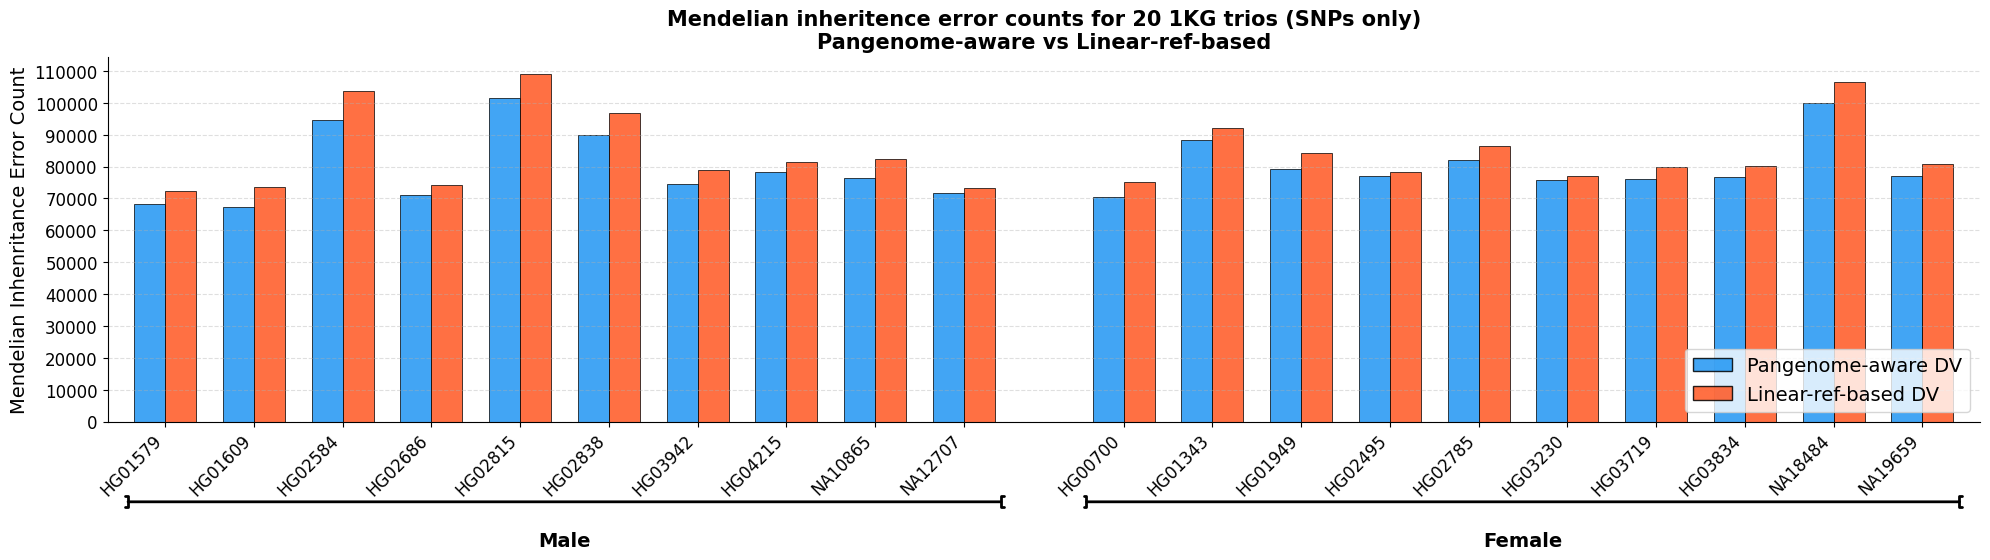

Plot saved in results/barplot_mendelian_error_counts_by_sample_SNP.pdf


In [92]:
plot_mendelian_barplots(results = pd.read_csv("results/Mendelian_1KG_20_trios_stats_SNP.tsv", sep='\t'), 
                        title = 'Mendelian inheritence error counts for 20 1KG trios (SNPs only)\nPangenome-aware vs Linear-ref-based',
                        metric = 'Mendelian_Inhenritance_Error', 
                        metric_lbl = 'Mendelian Inhenritance Error Count', 
                        max_y = 120000, 
                        step_y = 10000, 
                        out_pdf_path = 'results/barplot_mendelian_error_counts_by_sample_SNP.pdf')

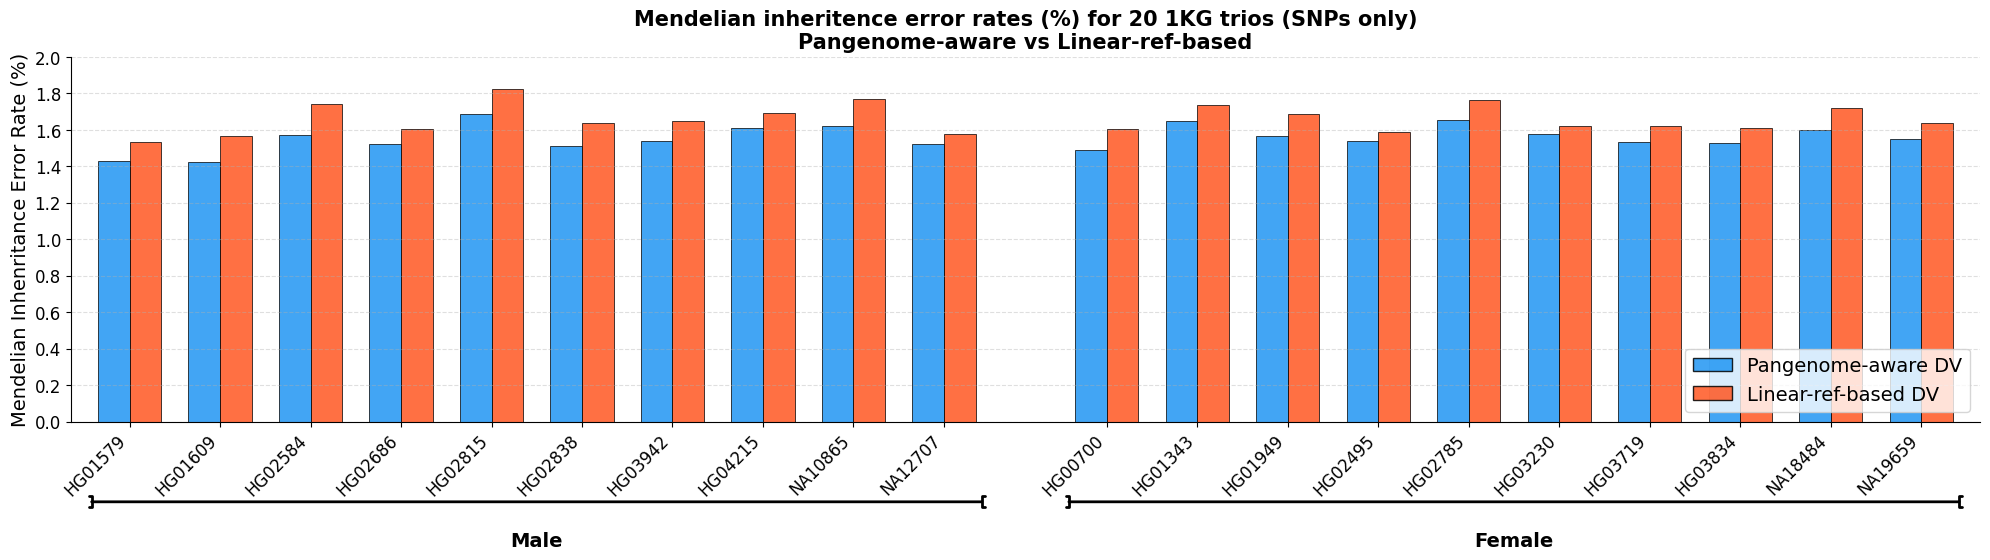

Plot saved in results/barplot_mendelian_error_rates_by_sample_SNP.pdf


In [105]:
plot_mendelian_barplots(results = pd.read_csv("results/Mendelian_1KG_20_trios_stats_SNP.tsv", sep='\t'), 
                        title = 'Mendelian inheritence error rates (%) for 20 1KG trios (SNPs only)\nPangenome-aware vs Linear-ref-based',
                        metric = 'Mendelian_Inhenritance_Error_Rate', 
                        metric_lbl = 'Mendelian Inhenritance Error Rate (%)', 
                        max_y = 2.05, 
                        step_y = 0.2, 
                        out_pdf_path = 'results/barplot_mendelian_error_rates_by_sample_SNP.pdf')

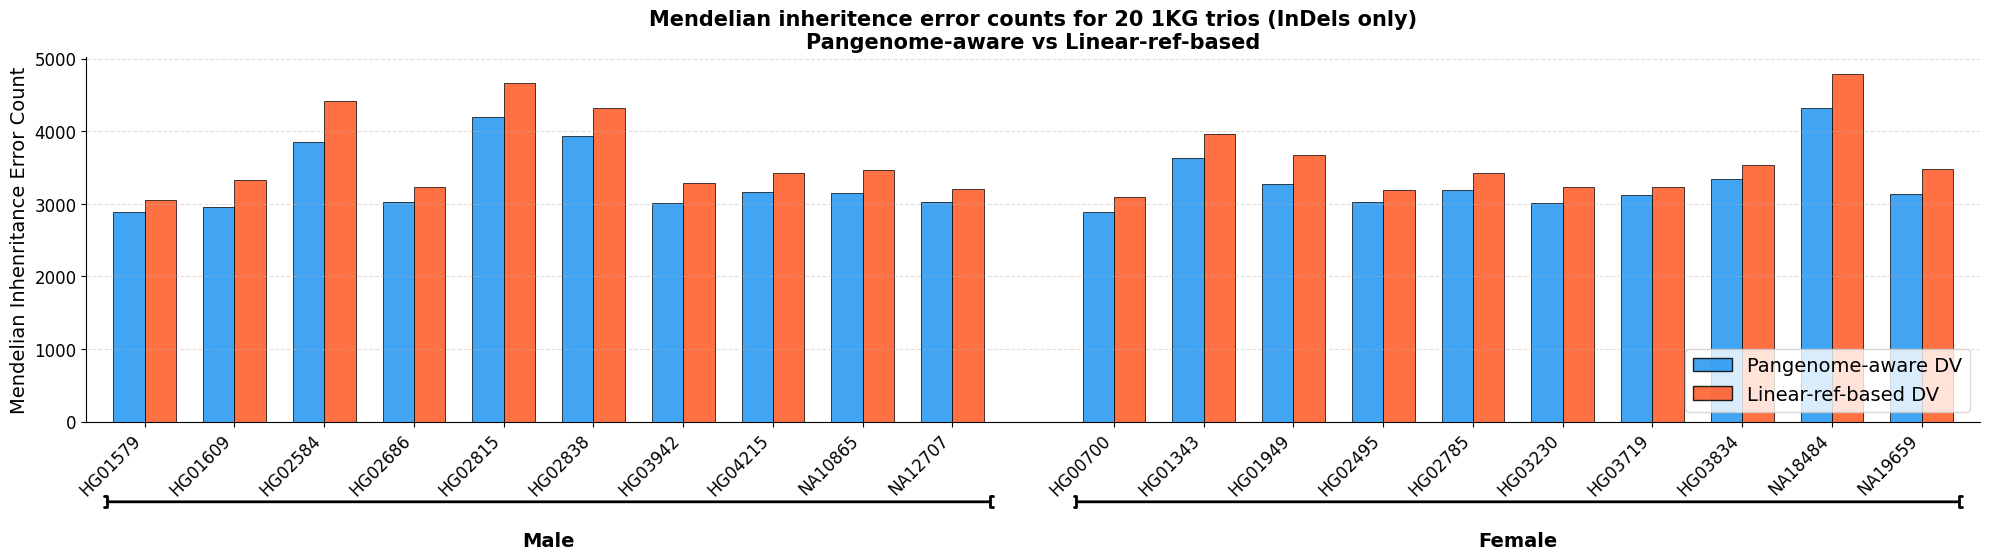

Plot saved in results/barplot_mendelian_error_counts_by_sample_InDel.pdf


In [96]:
plot_mendelian_barplots(results = pd.read_csv("results/Mendelian_1KG_20_trios_stats_InDel.tsv", sep='\t'), 
                        title = 'Mendelian inheritence error counts for 20 1KG trios (InDels only)\nPangenome-aware vs Linear-ref-based',
                        metric = 'Mendelian_Inhenritance_Error', 
                        metric_lbl = 'Mendelian Inhenritance Error Count', 
                        max_y = 6000, 
                        step_y = 1000, 
                        out_pdf_path = 'results/barplot_mendelian_error_counts_by_sample_InDel.pdf')

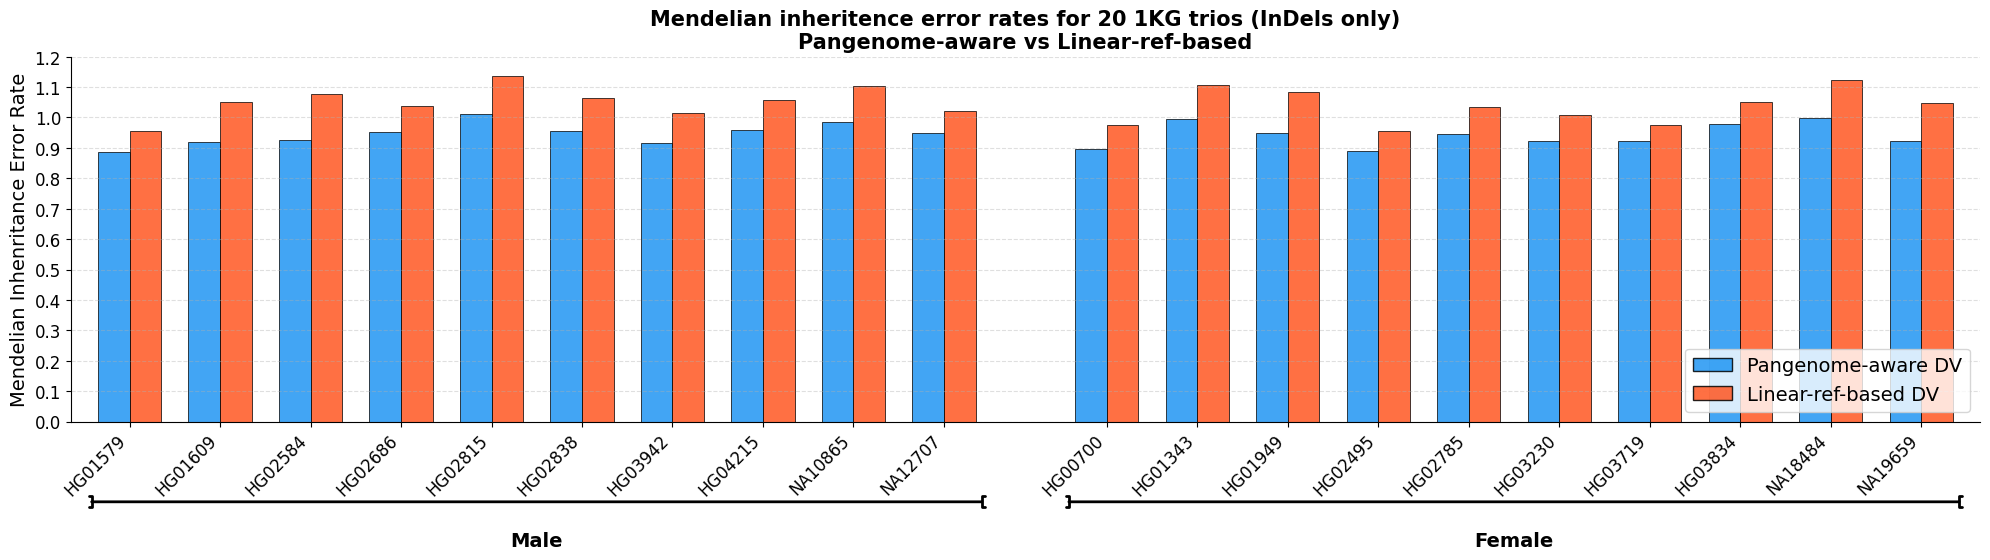

Plot saved in results/barplot_mendelian_error_rates_by_sample_InDel.pdf


In [100]:
plot_mendelian_barplots(results = pd.read_csv("results/Mendelian_1KG_20_trios_stats_InDel.tsv", sep='\t'), 
                        title = 'Mendelian inheritence error rates for 20 1KG trios (InDels only)\nPangenome-aware vs Linear-ref-based',
                        metric = 'Mendelian_Inhenritance_Error_Rate', 
                        metric_lbl = 'Mendelian Inhenritance Error Rate', 
                        max_y = 1.25, 
                        step_y = 0.1, 
                        out_pdf_path = 'results/barplot_mendelian_error_rates_by_sample_InDel.pdf')